In [47]:
import numpy as np
import pandas as pd

In [48]:
1. # Load clean_orders file
orders=pd.read_csv('cleaned_orders.csv')

# A . RFM Metrices

In [49]:
orders.head()

,order_id,customer_id,city,order_timestamp,status,payment_method,rider_id,delivery_time_mins,gross_amount,discount,delivery_fee,platform_fee,net_amount,order_date,order_hour,day_of_week,is_weekend
0,ORD500000,C114573,Chennai,2026-05-19 20:20:00,Delivered,COD,R1735,16.0,224.24,29.13,0,3.00,198.11,2026-05-19,20,Tuesday,0
1,ORD500001,C117353,Delhi,2026-05-19 15:22:00,Delivered,UPI,R1230,38.0,248.96,0.00,0,5.05,254.01,2026-05-19,15,Tuesday,0
2,ORD500002,C109281,Delhi,2026-05-19 19:44:00,Delivered,UPI,R1035,22.0,263.83,0.00,15,3.53,282.36,2026-05-19,19,Tuesday,0
3,ORD500003,C115595,Delhi,2026-05-19 16:22:00,Delivered,UPI,R1137,44.0,112.07,0.00,35,4.97,152.04,2026-05-19,16,Tuesday,0
4,ORD500004,C102888,Bangalore,2026-05-19 07:20:00,Delivered,UPI,R1357,29.0,228.04,30.96,15,5.16,217.24,2026-05-19,7,Tuesday,0


In [50]:
2. # change order_date column from text to real date format

2.0

In [51]:
orders['order_date']=pd.to_datetime(orders['order_date'])

In [52]:
3. #  ek Rference Data banana
    # data ki sabse aakhri date se 1 din aage ki date lege

3.0

In [53]:
latest_date_in_data=orders['order_date'].max()
latest_date_in_data

Timestamp('2026-08-17 00:00:00')

In [54]:
4. # for day extend
ref_date=latest_date_in_data + pd.Timedelta(days=1)

In [55]:
5.# Each Customer ke liye max_date,order count,total bill nikalo

5.0

In [56]:
rfm=orders.groupby('customer_id').agg(
    last_order_date=('order_date','max'),
    frequency=('order_id','count'),
    monetary=('net_amount','sum')
).reset_index()

In [57]:
6.# Rfm Check
rfm.head()

,customer_id,last_order_date,frequency,monetary
0,C100000,2026-07-25,6,1106.96
1,C100001,2026-05-20,1,175.99
2,C100003,2026-06-13,2,372.45
3,C100004,2026-07-06,1,146.14
4,C100005,2026-08-06,5,1244.93


In [58]:
7.# calculate Recerncy in days

7.0

In [59]:
rfm['Recency']=(ref_date-rfm['last_order_date']).dt.days

In [60]:
rfm.head()

,customer_id,last_order_date,frequency,monetary,Recency
0,C100000,2026-07-25,6,1106.96,24
1,C100001,2026-05-20,1,175.99,90
2,C100003,2026-06-13,2,372.45,66
3,C100004,2026-07-06,1,146.14,43
4,C100005,2026-08-06,5,1244.93,12


In [61]:
8. # Final RFM Table after clan

8.0

In [62]:
rfm = rfm[['customer_id','Recency','frequency','monetary']]

In [63]:
# columns name standard format matlab capitalise ho jayege
rfm.columns = ['Customer_id','Recency','Frequency','Monetary']

In [64]:
rfm.head()

,Customer_id,Recency,Frequency,Monetary
0,C100000,24,6,1106.96
1,C100001,90,1,175.99
2,C100003,66,2,372.45
3,C100004,43,1,146.14
4,C100005,12,5,1244.93


# B. Log Transformation Apply

In [65]:
# 1. rfm table ka ek naya copy create karte hai for transformation

rfm_log=pd.DataFrame()

In [66]:
# 2. refernce lege customer id ka 
rfm_log['Customer_id']= rfm['Customer_id']

In [67]:
# 3. teno column par log transformation lagate hai

rfm_log['Recency_log'] = np.log1p(rfm['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm['Monetary'])

In [68]:
rfm_log.head()

,Customer_id,Recency_log,Frequency_log,Monetary_log
0,C100000,3.218876,1.945910,7.010276
1,C100001,4.510860,0.693147,5.176093
2,C100003,4.204693,1.098612,5.922784
3,C100004,3.784190,0.693147,4.991385
4,C100005,2.564949,1.791759,7.127638


# C. Feature Scaling ( StandaradScalar )

In [69]:
# library import
from sklearn.preprocessing import StandardScaler 

In [70]:
scaler= StandardScaler()

In [71]:
# only select no. wale column
features_to_scale = rfm_log[['Recency_log','Frequency_log','Monetary_log']]

In [72]:
# fit (Data ko padhna aur samajhna)
# transform (Numbers ko nayi scale par badalna)
# Recency_log, Frequency_log, aur Monetary_log teeno ke averages aur spreads nikale (fit).
# Har customer ki values ko -3 se +3 ke beech ke standard scale par convert kar diya (transform).
# Output ko rfm_scaled_array naam ke variable mein store kar diya

In [73]:
rfm_scaled_array=scaler.fit_transform(features_to_scale)

In [74]:
# agai make the recent created table
rfm_scaled=pd.DataFrame(
    rfm_scaled_array,
    columns=['Recency_scaled','Frequency_scaled','Monetary_scaled']
)

In [75]:
# output check
rfm_scaled.head()

,Recency_scaled,Frequency_scaled,Monetary_scaled
0,0.434295,1.121951,0.784902
1,1.722292,-1.290215,-1.107657
2,1.417069,-0.509501,-0.337201
3,0.997864,-1.290215,-1.298244
4,-0.217614,0.825138,0.905999


# D. K-Mean Clustering and Elbow Method

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [77]:
# 1. make list for store values
inertia_list=[]

In [78]:
# to check data fitting in groups
# K=1 se 10 tak chalega for group test
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia_list.append(kmeans.inertia_)

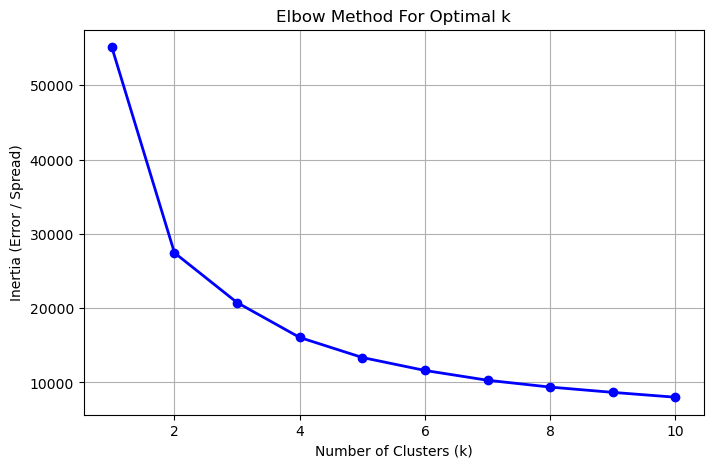

In [79]:
# chart
plt.figure(figsize=(8,5)) # blank Canvas
plt.plot(range(1,11),inertia_list,marker='o',color='b',linewidth=2)
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Error / Spread)')
plt.grid(True)
plt.show()

# E. Final Model Traning & Cluster Tagging(Label assign karna)

In [80]:
#1. Final K-Mean model banaya 4 cluster ke saath
kmeans_final = KMeans(n_clusters=4,random_state=42, n_init=10)

#2. Model train kiya or har customer ko group id(0,1,2,3) assign kiya
rfm['Cluster']=kmeans_final.fit_predict(rfm_scaled)

#3. Check kiya ki har group me kitni customers aaye 
print("---har grop me customer count---")
print(rfm['Cluster'].value_counts())

#4. check table cluster column juda ya nahi
rfm.head()

---har grop me customer count---
Cluster
3    5569
2    4923
0    4585
1    3298
Name: count, dtype: int64


,Customer_id,Recency,Frequency,Monetary,Cluster
0,C100000,24,6,1106.96,3
1,C100001,90,1,175.99,2
2,C100003,66,2,372.45,2
3,C100004,43,1,146.14,2
4,C100005,12,5,1244.93,0


# F. Cluster Profiling (Analysis & Business Naming)

In [81]:
# 1.: Har cluster ka mean (average) RFM calculate karo
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

# Column names ko clean dikhane ke liye
cluster_analysis.columns = ['Avg_Recency_Days', 'Avg_Frequency_Orders', 'Avg_Monetary_Spend', 'Total_Customers']

# Final table display karo
print("--- Cluster Profiling Summary ---")
cluster_analysis

--- Cluster Profiling Summary ---


,Avg_Recency_Days,Avg_Frequency_Orders,Avg_Monetary_Spend,Total_Customers
Cluster,,,,
0,7.46,6.96,1578.54,4585
1,5.88,2.48,486.16,3298
2,45.81,1.23,204.39,4923
3,28.83,3.26,751.76,5569


C:\Users\Krish\AppData\Local\Temp\ipykernel_820\3916359937.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


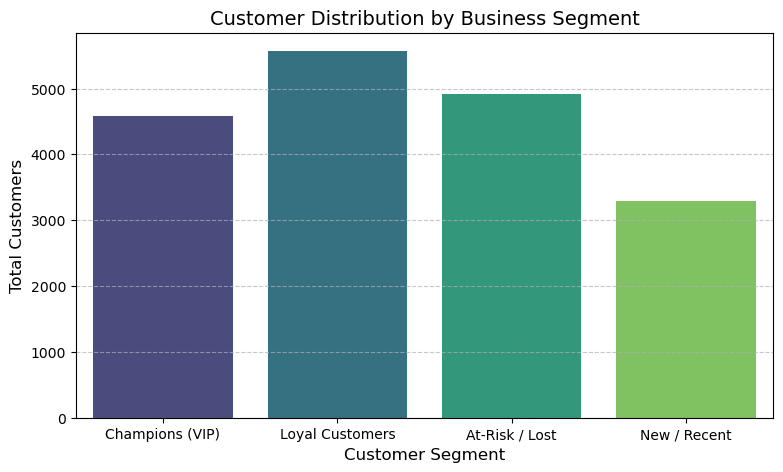

,Customer_id,Recency,Frequency,Monetary,Segment
0,C100000,24,6,1106.96,Loyal Customers
1,C100001,90,1,175.99,At-Risk / Lost
2,C100003,66,2,372.45,At-Risk / Lost
3,C100004,43,1,146.14,At-Risk / Lost
4,C100005,12,5,1244.93,Champions (VIP)


In [82]:
# 2.
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dictionary banayi jo numbers ko business names ke sath match karegi
segment_map = {
    0: 'Champions (VIP)',
    1: 'New / Recent',
    2: 'At-Risk / Lost',
    3: 'Loyal Customers'
}

# 2. Har customer ke aage uska business segment name joda
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# 3. Bar Chart Draw kiya (Visualization)
plt.figure(figsize=(9, 5))
sns.countplot(
    data=rfm, 
    x='Segment', 
    palette='viridis', 
    order=['Champions (VIP)', 'Loyal Customers', 'At-Risk / Lost', 'New / Recent']
)
plt.title('Customer Distribution by Business Segment', fontsize=14)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Final output table check ki
rfm[['Customer_id', 'Recency', 'Frequency', 'Monetary', 'Segment']].head()

In [83]:
# 3. Final Data export
# Segmented customers ko CSV file me save karo
rfm.to_csv('Customer_Segmentation_Results.csv', index=False)
print("File successfully saved as 'Customer_Segmentation_Results.csv'")

File successfully saved as 'Customer_Segmentation_Results.csv'


# G. Segment-to-Business Insights & Mapping

In [84]:
# Order load
orders_df=pd.read_csv('cleaned_orders.csv')

In [88]:
# small 'customer_id' ko Capital 'Customer_id' bana diya
orders_df.rename(columns={'customer_id': 'Customer_id'}, inplace=True)

In [89]:
# dono table ko merge kar diya
merged_blinkit = pd.merge(orders_df, rfm[['Customer_id', 'Segment']], on='Customer_id', how='left')

In [90]:
# top 3 rows
merged_blinkit[['order_id', 'Customer_id', 'city', 'net_amount', 'Segment']].head(3)

,order_id,Customer_id,city,net_amount,Segment
0,ORD500000,C114573,Chennai,198.11,Champions (VIP)
1,ORD500001,C117353,Delhi,254.01,Champions (VIP)
2,ORD500002,C109281,Delhi,282.36,At-Risk / Lost


In [91]:
# net sales acc. to city and segmnet
city_segment_sales=merged_blinkit.groupby(['city','Segment'])['net_amount'].sum().unstack().round(2)

In [92]:
city_segment_sales

Segment,At-Risk / Lost,Champions (VIP),Loyal Customers,New / Recent
city,,,,
Bangalore,203890.15,1459114.43,828190.22,315903.65
Chennai,99318.56,672067.00,434619.65,172939.09
Delhi,244604.96,1769346.69,1010945.56,364962.50
Hyderabad,124677.11,895044.67,500686.28,194928.55
Kolkata,88176.91,652029.55,373390.52,145722.35
Mumbai,139677.45,1000091.24,589529.29,226078.20
Pune,105848.77,789909.03,449164.84,182812.24


In [93]:
#  Segment and Payment Method ka percentage distribution nikalna
payment_segment = pd.crosstab(merged_blinkit['Segment'], merged_blinkit['payment_method'], normalize='index').round(4) * 100

#  Table print karna
payment_segment

payment_method,COD,Card,UPI,Wallet
Segment,,,,
At-Risk / Lost,17.15,4.12,70.85,7.88
Champions (VIP),16.73,4.17,71.25,7.84
Loyal Customers,17.21,4.05,71.09,7.65
New / Recent,17.53,4.29,70.16,8.01


In [94]:
#  Har segment ka average delivery time (minutes) calculate karna
delivery_segment = merged_blinkit.groupby('Segment')['delivery_time_mins'].mean().round(2).reset_index()

#  Table print karna
delivery_segment

,Segment,delivery_time_mins
0,At-Risk / Lost,29.53
1,Champions (VIP),29.50
2,Loyal Customers,29.62
3,New / Recent,29.38


#  H Business insights

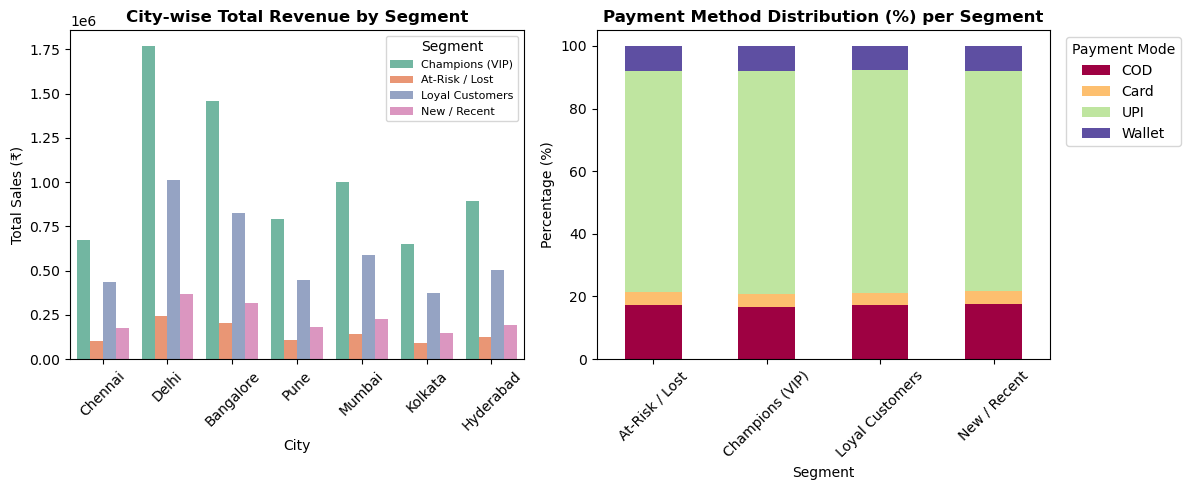

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Canvas ka size set karna
plt.figure(figsize=(12, 5))

# 2. City vs Net Sales per Segment ka Bar Chart
plt.subplot(1, 2, 1)
sns.barplot(
    data=merged_blinkit,
    x='city',
    y='net_amount',
    hue='Segment',
    estimator=sum,
    errorbar=None,
    palette='Set2'
)
plt.title('City-wise Total Revenue by Segment', fontsize=12, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.legend(title='Segment', fontsize=8)

# 3. Payment Method Distribution ka Stacked Bar Chart
plt.subplot(1, 2, 2)
payment_segment.plot(kind='bar', stacked=True, colormap='Spectral', ax=plt.gca())
plt.title('Payment Method Distribution (%) per Segment', fontsize=12, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Payment Mode', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# I Final Data Export

In [96]:
# . Master dataset ko CSV format mein export karna
merged_blinkit.to_csv('Blinkit_Final_Segmented_Master_Data.csv', index=False)

#  Confirma print karna
print("Master File Export Complete!")
print(f"Total Rows: {merged_blinkit.shape[0]}")
print(f"Total Columns: {merged_blinkit.shape[1]}")

Master File Export Complete!
Total Rows: 64325
Total Columns: 18
